In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("../../DataSet/matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
df.shape

(1095, 20)

In [4]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [10]:
df.drop('method', axis=1, inplace=True)
df

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,1426307,2024,Hyderabad,2024-05-19,League,Abhishek Sharma,"Rajiv Gandhi International Stadium, Uppal, Hyd...",Punjab Kings,Sunrisers Hyderabad,Punjab Kings,bat,Sunrisers Hyderabad,wickets,4.0,215.0,20.0,N,Nitin Menon,VK Sharma
1091,1426309,2024,Ahmedabad,2024-05-21,Qualifier 1,MA Starc,"Narendra Modi Stadium, Ahmedabad",Sunrisers Hyderabad,Kolkata Knight Riders,Sunrisers Hyderabad,bat,Kolkata Knight Riders,wickets,8.0,160.0,20.0,N,AK Chaudhary,R Pandit
1092,1426310,2024,Ahmedabad,2024-05-22,Eliminator,R Ashwin,"Narendra Modi Stadium, Ahmedabad",Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,4.0,173.0,20.0,N,KN Ananthapadmanabhan,MV Saidharshan Kumar
1093,1426311,2024,Chennai,2024-05-24,Qualifier 2,Shahbaz Ahmed,"MA Chidambaram Stadium, Chepauk, Chennai",Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,Sunrisers Hyderabad,runs,36.0,176.0,20.0,N,Nitin Menon,VK Sharma


In [17]:
df.isnull().sum()

id                  0
season              0
city                0
date                0
match_type          0
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
umpire1             0
umpire2             0
dtype: int64

In [16]:
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['city'].isnull().sum()

np.int64(0)

In [22]:
df['player_of_match'] = df['player_of_match'].fillna('unknown')
df['player_of_match']

0           BB McCullum
1            MEK Hussey
2           MF Maharoof
3            MV Boucher
4             DJ Hussey
             ...       
1090    Abhishek Sharma
1091           MA Starc
1092           R Ashwin
1093      Shahbaz Ahmed
1094           MA Starc
Name: player_of_match, Length: 1095, dtype: object

In [25]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'umpire1', 'umpire2'],
      dtype='object')

In [30]:
win =df['winner'].value_counts()

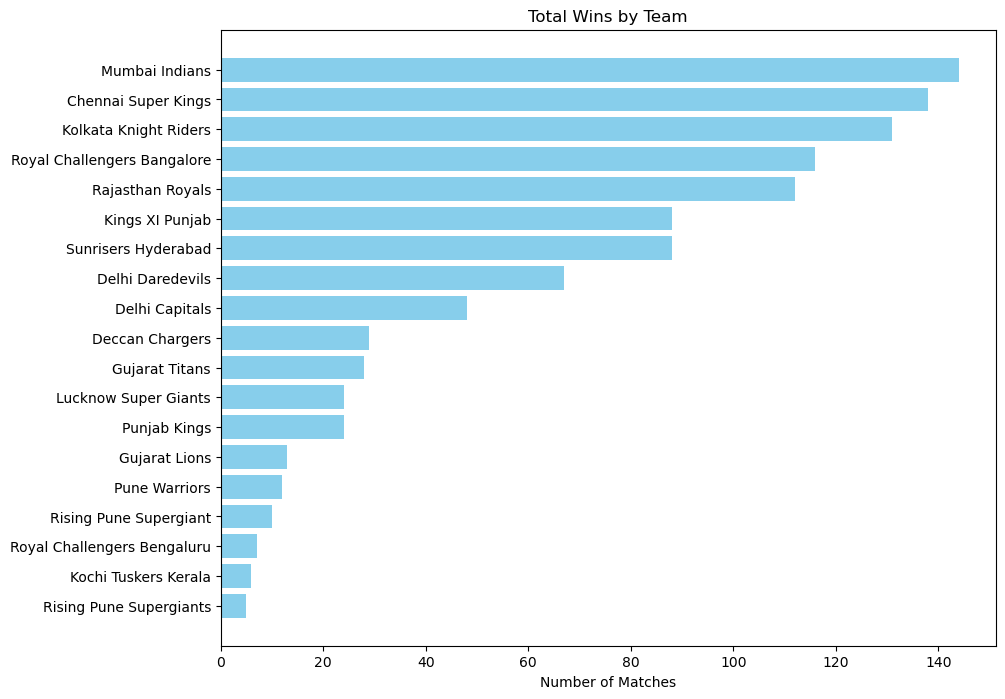

In [41]:
plt.figure(figsize=(10, 8))
plt.barh(y=win.index, width=win.values, color='skyblue')
plt.gca().invert_yaxis()  # most wins phele 
plt.title('Total Wins by Team')
plt.xlabel('Number of Matches')
plt.show()

In [46]:
df['toss_match_winner'] = df['toss_winner'] == df['winner']
df['toss_match_winner']

0       False
1        True
2       False
3       False
4       False
        ...  
1090    False
1091    False
1092     True
1093    False
1094    False
Name: toss_match_winner, Length: 1095, dtype: bool

In [43]:
top_players = df['player_of_match'].value_counts().head(10)
top_players

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           18
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         16
AD Russell        15
Name: count, dtype: int64

In [44]:
df.isnull().sum()

id                    0
season                0
city                  0
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
umpire1               0
umpire2               0
toss_match_winner     0
dtype: int64

In [48]:
win_types = df['result'].value_counts()
win_types

result
wickets      578
runs         498
tie           14
no result      5
Name: count, dtype: int64

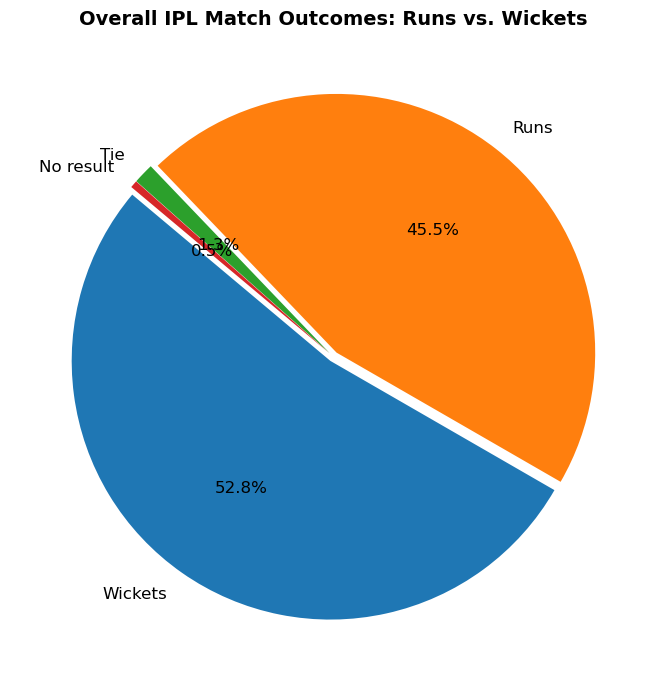

In [47]:
# Check the exact distribution of the 'result' column
win_types = df['result'].value_counts()

# Plotting the overall distribution as a Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(
    win_types.values, 
    labels=win_types.index.str.capitalize(), 
    autopct='%1.1f%%', 
    colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(win_types)], 
    startangle=140, 
    explode=[0.02] * len(win_types),
    textprops={'fontsize': 12}
)
plt.title('Overall IPL Match Outcomes: Runs vs. Wickets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

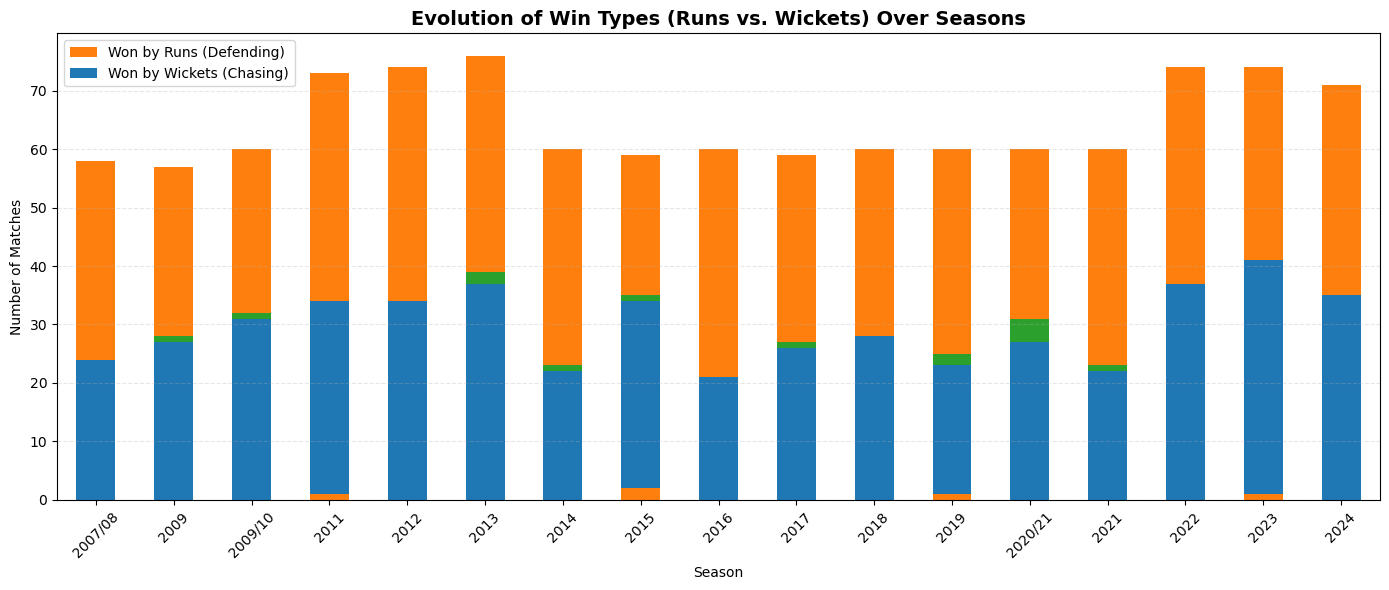

In [52]:
season_result = df.groupby(['season', 'result']).size().unstack().fillna(0)

season_result.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#ff7f0e', '#1f77b4', '#2ca02c'])
plt.title('Evolution of Win Types (Runs vs. Wickets) Over Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.legend(['Won by Runs (Defending)', 'Won by Wickets (Chasing)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
season_result

result,no result,runs,tie,wickets
season,,,,
2007/08,0.0,24.0,0.0,34.0
2009,0.0,27.0,1.0,29.0
2009/10,0.0,31.0,1.0,28.0
2011,1.0,33.0,0.0,39.0
2012,0.0,34.0,0.0,40.0
2013,0.0,37.0,2.0,37.0
2014,0.0,22.0,1.0,37.0
2015,2.0,32.0,1.0,24.0
2016,0.0,21.0,0.0,39.0


In [57]:
x = df[(df['toss_decision']== 'bat') &  (df['winner'])]['id'].count()
x

np.int64(390)

In [58]:
y = df[(df['toss_decision']== 'field') &  (df['winner'])]['id'].count()
y

np.int64(700)